# Two-moons demonstration

This notebook runs all eight reverse-OU methods with identical training data and random inputs. The figure is a qualitative demonstration, not evidence of comparative superiority. The default execution uses 300 training samples, 10,000 reference samples, 2,000 generated particles, and 300 reverse steps.

## Methods

The columns show plain score matching, Stein-informed score matching, scalar Stein transport, and vectorized Stein transport. The first row uses the deterministic probability-flow ODE and the second row uses the stochastic reverse SDE.

In [1]:
import json
import os

import torch
from IPython.display import Image, Markdown, display

from stein_generative_modeling.two_moon import (
    TwoMoonConfig,
    run_experiment,
    smoke_config,
)

In [2]:
mode = os.environ.get("STEIN_NOTEBOOK_MODE", "full").lower()
if mode not in {"full", "smoke"}:
    raise ValueError("STEIN_NOTEBOOK_MODE must be 'full' or 'smoke'")
config = smoke_config() if mode == "smoke" else TwoMoonConfig()
display(Markdown(f"**Execution mode:** `{mode}`"))
config

**Execution mode:** `full`

TwoMoonConfig(dimension=2, training_size=300, reference_size=10000, generated_size=2000, target_noise=0.05, horizon=3.0, reverse_steps=300, regularization=0.001, scaling_factor=1.0, device='cpu', dtype='float64', seeds={'training': 2025, 'reference': 2026, 'initial_particles': 2027, 'forward_noise': 2028, 'reverse_brownian': 2029})

In [3]:
run_dir = run_experiment(config, progress=False)
print(f"Completed run: {run_dir.name}")

Completed run: seed2025_20260923T210242.597833Z


In [4]:
resolved = json.loads((run_dir / "config.json").read_text())
metadata = json.loads((run_dir / "run_metadata.json").read_text())
outputs = torch.load(run_dir / "samples.pt", map_location="cpu", weights_only=False)
status = {name: item["status"] for name, item in outputs.items()}
display(
    {
        "configuration": resolved,
        "method_status": status,
        "failures": metadata["failures"],
    }
)

{'configuration': {'device': 'cpu',
  'dimension': 2,
  'dtype': 'float64',
  'generated_size': 2000,
  'horizon': 3.0,
  'method_labels': {'sm_plain_det': '$\\mathrm{SM}_{\\mathrm{plain}}^{\\mathrm{det}}$',
   'sm_plain_sto': '$\\mathrm{SM}_{\\mathrm{plain}}^{\\mathrm{sto}}$',
   'sm_stein_det': '$\\mathrm{SM}_{\\mathrm{stein}}^{\\mathrm{det}}$',
   'sm_stein_sto': '$\\mathrm{SM}_{\\mathrm{stein}}^{\\mathrm{sto}}$',
   'st_det': '$\\mathrm{ST}^{\\mathrm{det}}$',
   'st_sto': '$\\mathrm{ST}^{\\mathrm{sto}}$',
   'st_vec_det': '$\\mathrm{ST}_{\\mathrm{vec}}^{\\mathrm{det}}$',
   'st_vec_sto': '$\\mathrm{ST}_{\\mathrm{vec}}^{\\mathrm{sto}}$'},
  'methods': ['sm_plain_det',
   'sm_stein_det',
   'st_det',
   'st_vec_det',
   'sm_plain_sto',
   'sm_stein_sto',
   'st_sto',
   'st_vec_sto'],
  'reference_size': 10000,
  'regularization': 0.001,
  'reverse_steps': 300,
  'scaling_factor': 1.0,
  'seeds': {'forward_noise': 2028,
   'initial_particles': 2027,
   'reference': 2026,
   'reverse_

## Target reference

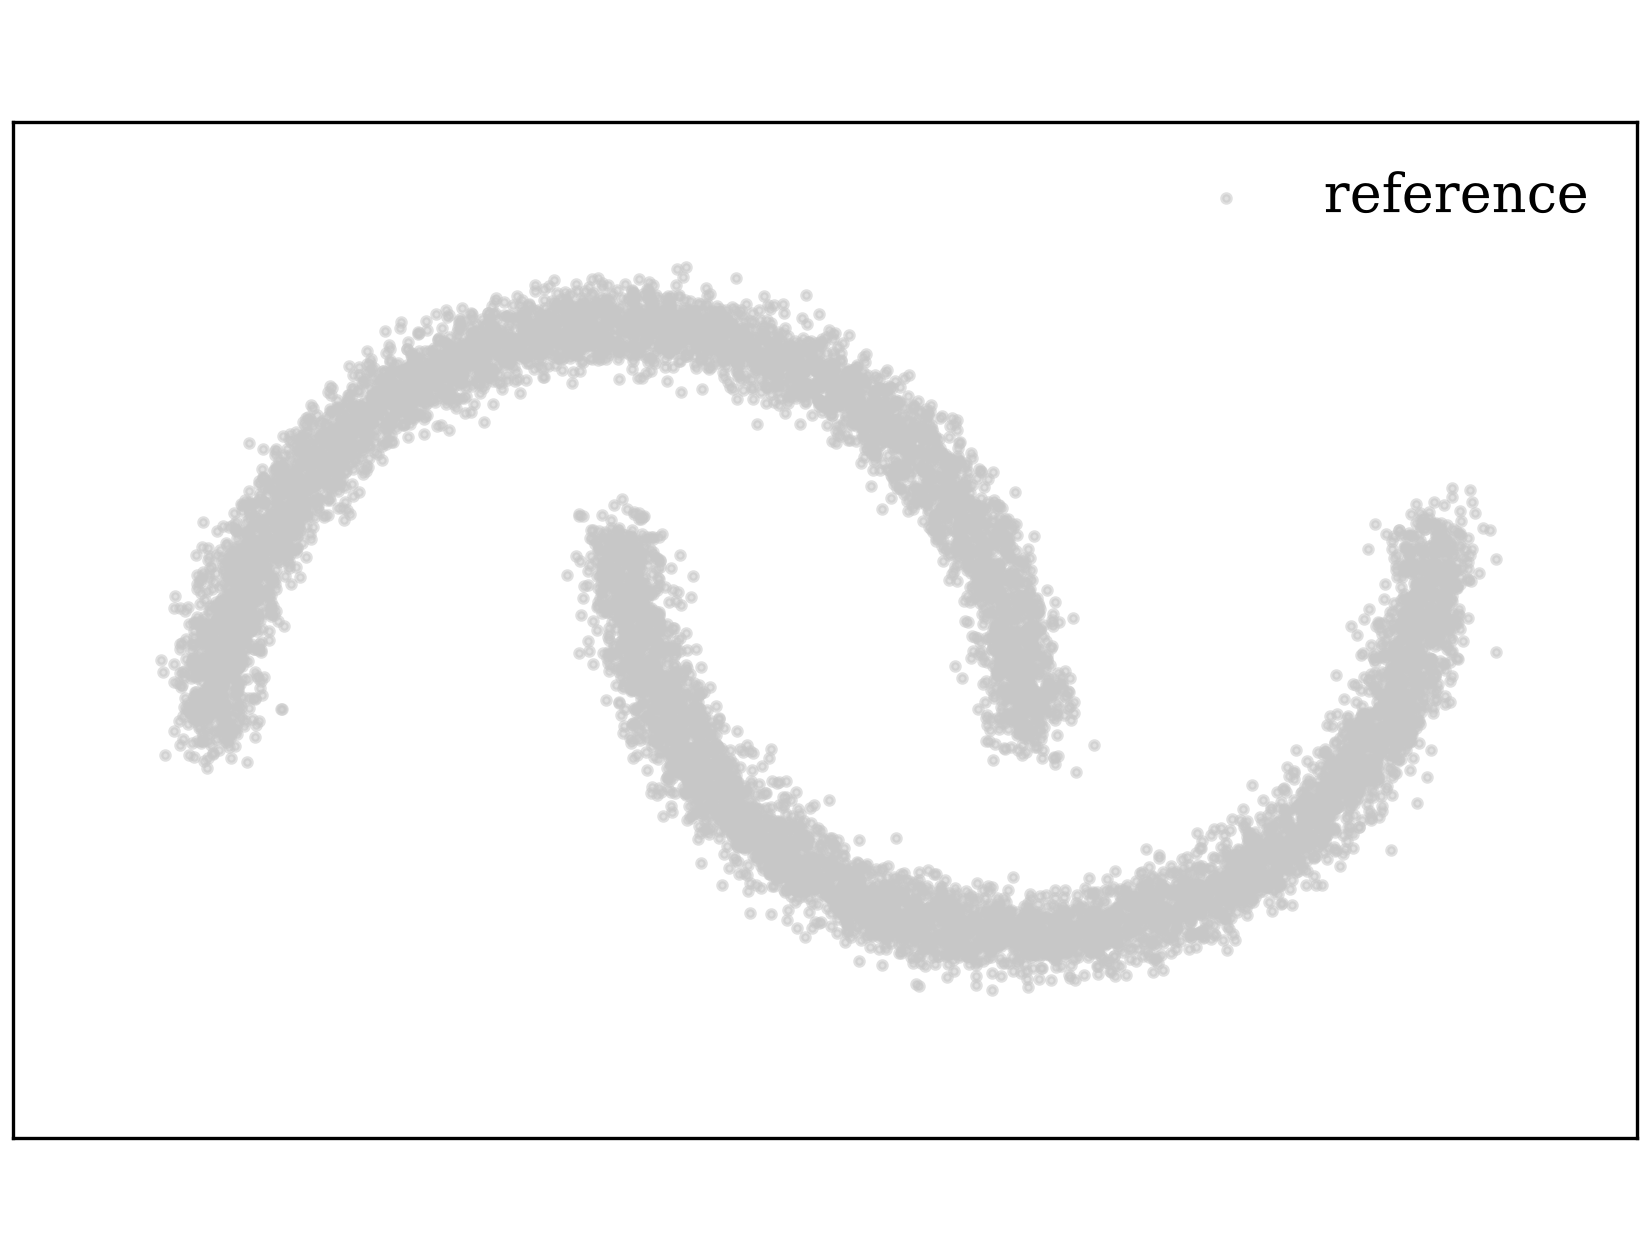

## Eight-method comparison

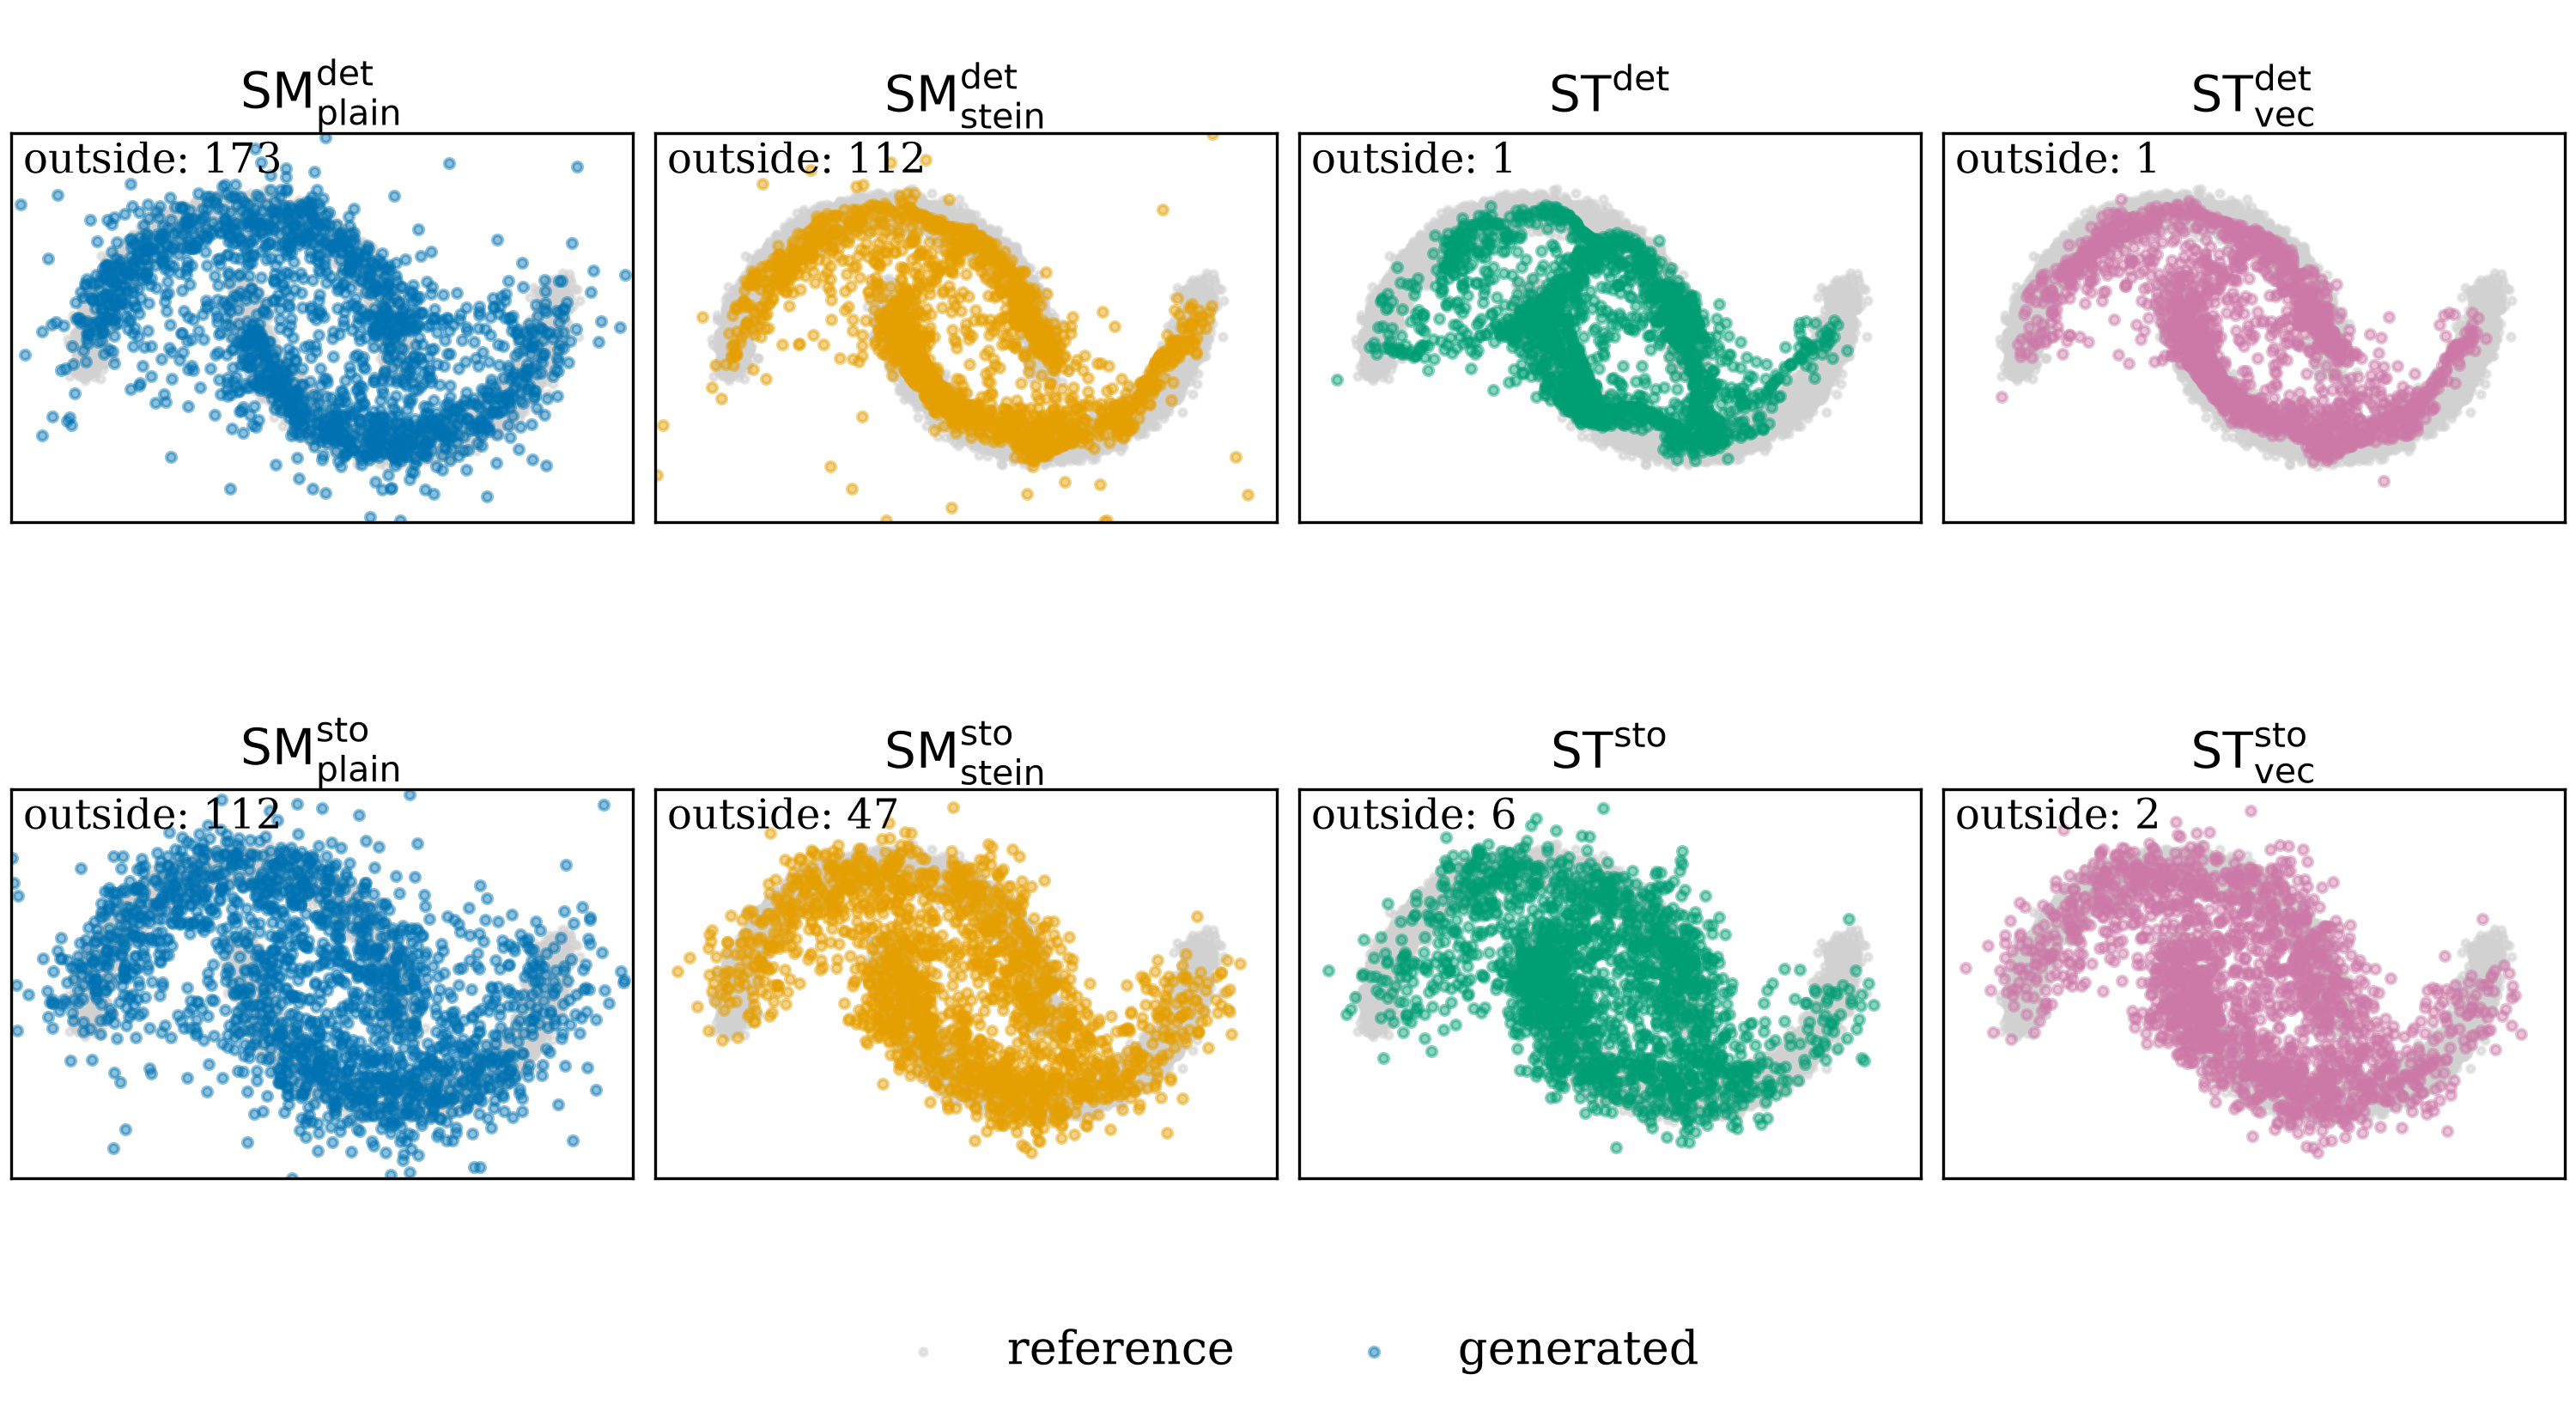

In [5]:
display(Markdown("## Target reference"))
display(Image(filename=str(run_dir / "reference.png")))
display(Markdown("## Eight-method comparison"))
display(Image(filename=str(run_dir / "comparison.png")))